In [52]:
import re
import matplotlib
import numpy as np
import pandas as pd
from scipy.signal import find_peaks
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import nist_helper
import io
from IPython.display import Image, display
import utils
import nist_codes
import generic_render
import matplotlib.text as mtext
from PIL import Image as PILImage

In [53]:
X_MIN = 400
X_MAX = 750
FIG_SIZE = (15,3)
MIN_NEEDLE_WIDTH = 0.1
MAX_NEEDLE_WIDTH = 0.3
DPI = 600
MAX_Y_SCALE = 0.75
NEEDLE_POWER_SHAPE = 4
LABEL_NORM_INT = 0.20
GLOW_WIDTH_MULT = 1.3

NORM_PROM_PERC = 0.15
NORM_MIN_BRIGHT = 0.01
NORM_GLOW_ALPHA = 0
NORM_PEAK_EMPHASIS = 1.1
NORM_PEAK_LABEL_POSN = 0.75

DEFAULT_PROM_PERC = 0.08
DEFAULT_MIN_BRIGHT = 0.1
DEFAULT_GLOW_ALPHA = 0.35
DEFAULT_PEAK_EMPHASIS = 1.4
DEFAULT_PEAK_LABEL_POSN = 0.77

detection_col = '_raw_int'
int_col = '_adj_int'

fig_height_base = 3.0
fig_width = 15
max_needle_y = 0.75
fig_height_overflow_scale = 9.0
peak_label_y = 0.77

In [60]:
def plot_spec(
    data_df,
    nm_col=None,
    int_col=None,
    prominence_percentage=0,
    x_min=X_MIN,
    x_max=X_MAX,
    fig_size=(fig_width, fig_height_base),
    min_brightness=0,
    min_needle_max_width_nm=MIN_NEEDLE_WIDTH,
    max_needle_max_width_nm=MAX_NEEDLE_WIDTH,
    needle_shape_power=NEEDLE_POWER_SHAPE,
    glow_width_multiplier=GLOW_WIDTH_MULT,
    glow_alpha=0,
    dpi=DPI,
    mode='dark',
    peak_label_y_position=None,
    max_needle_y_scale=0,
    peak_wavelengths=None,
    force_nist=None,
    apply_descriptor_adjustments=False,
    show_peak_labels=True,
    label_min_norm_int=LABEL_NORM_INT,
    generic_type=None,
):
    # Resolve column names at runtime (accept many common aliases)
    if nm_col is None:
        nm_col = utils.resolve_column(data_df, utils.lambda_tokens, "wavelength",)
    if int_col is None:
        int_col = utils.resolve_column(data_df, utils.int_tokens, "intensity",)

    # Always parse NIST-style intensity cells first because descriptors are usually attached.
    df_plot_data = data_df.copy()
    df_plot_data[nm_col] = pd.to_numeric(df_plot_data[nm_col], errors='coerce')

    # run NIST detector
    has_any_nist, nist_diag = nist_codes.detect_nist_values(df_plot_data[int_col], force_nist=force_nist)

    if has_any_nist:
        df_plot_data = nist_codes.prepare_nist_spectrum(df_plot_data, int_col, apply_descriptor_adjustments)
        min_brightness = DEFAULT_MIN_BRIGHT
        glow_alpha = DEFAULT_GLOW_ALPHA
        prominence_percentage = DEFAULT_PROM_PERC
        peak_label_y_position = DEFAULT_PEAK_LABEL_POSN
        print('NIST Destriptors Detected. Preparing NIST Rendering.')

    else:
        df_plot_data = generic_render.prepare_generic_spectrum(df_plot_data, int_col, apply_descriptor_adjustments)
        print('No NIST Destriptors Detected. Preparing Generic Rendering.')
        generic_type = (input('Choose Rendering: Raw or Normalised')).lower()
        if generic_type == 'raw':
            glow_alpha = DEFAULT_GLOW_ALPHA
            peak_label_y_position = DEFAULT_PEAK_LABEL_POSN
        elif generic_type == 'normalised':
            glow_alpha = NORM_GLOW_ALPHA
            peak_label_y_position = NORM_PEAK_LABEL_POSN

        # parse NIST-style cells
    parsed_intensity = df_plot_data[int_col].apply(nist_codes.parse_nist_intensity)
    df_plot_data['_raw_int'] = parsed_intensity.apply(lambda t: t[0])
    df_plot_data['_descriptor'] = parsed_intensity.apply(lambda t: t[1])

    # drop rows missing wavelength or numeric intensity
    df_plot_data = df_plot_data.dropna(subset=[nm_col, '_raw_int']).copy()
    df_plot_data = df_plot_data[(df_plot_data[nm_col] >= x_min) & (df_plot_data[nm_col] <= x_max)].copy()
    df_plot_data = df_plot_data.sort_values(by=nm_col).reset_index(drop=True)

    # returns empty figure for empty datasets
    if df_plot_data.empty:
        fig, ax = plt.subplots(figsize=fig_size, dpi=dpi)
        ax.set_axis_off()
        return fig

    # Normalize using the adjusted intensity
    min_int_val = df_plot_data['_adj_int'].min()
    max_int_val = df_plot_data['_adj_int'].max()
    int_range = max_int_val - min_int_val
    if int_range == 0 or np.isnan(int_range):
        df_plot_data['Norm_Int'] = 1.0
    else:
        df_plot_data['Norm_Int'] = (df_plot_data['_adj_int'] - min_int_val) / int_range

    if peak_wavelengths is not None:
        nm_vals = df_plot_data[nm_col].values
        peaks = []
        for pw in peak_wavelengths:
            try:
                pv = float(pw)
            except Exception:
                continue
            idx = int(np.argmin(np.abs(nm_vals - pv)))
            peaks.append(idx)
        peaks = sorted(set(peaks))
    elif has_any_nist:
        peaks = nist_codes.identify_spectral_peaks(df_plot_data.reset_index(drop=True), prominence_percentage, peak_wavelengths=None)
    else:
        raw_min = df_plot_data[detection_col].min()
        raw_max = df_plot_data[detection_col].max()
        raw_range = raw_max - raw_min
        if generic_type=='raw':
            prominence_percentage = DEFAULT_PROM_PERC
        if generic_type == 'normalised':
            prominence_percentage = NORM_PROM_PERC
        dynamic_prominence = prominence_percentage * (raw_range if raw_range != 0 else 1.0)
        peaks, _ = find_peaks(df_plot_data[int_col], prominence=dynamic_prominence)
    
    peak_nms = [float(df_plot_data.iloc[index][nm_col]) for index in peaks]
    peak_ints = [float(df_plot_data.iloc[index]["Norm_Int"]) for index in peaks]

    init_peak_label_y_posn = peak_label_y_position

    try:
        label_ys = utils.compute_label_positions(
            peak_nms,
            intensities=peak_ints,
            base_y=init_peak_label_y_posn,
            min_sep_nm=0.4,
            y_step=0.08,
            method="prefer_stronger_top",
            max_y=0.90,
        )
    except Exception:
        label_ys = [init_peak_label_y_posn] * len(peaks)

    if label_ys:
        max_label_y = max(label_ys)
        overflow = max(0, max_label_y - init_peak_label_y_posn)
        print("\noverflow:", overflow)
        print("o.g. peak label y pos'n:", init_peak_label_y_posn)
        if overflow > 0:
            new_height = fig_height_base + overflow * fig_height_overflow_scale
            fig_size = (fig_size[0], new_height)
            new_fig_height = new_height
           
            current_needle_height_in = max_needle_y * new_height
            new_needle_height = (max_needle_y * fig_height_base) / new_height 
            max_needle_y_scale = new_needle_height
            
            new_peak_y_posn = (peak_label_y * fig_height_base) / new_height
            peak_label_y_position = new_peak_y_posn
            
            print("needle height goal:", new_needle_height, "\n \t inches:", new_needle_height*new_height)
            print("current needle height (in):", current_needle_height_in)
            
            print("height:", new_height, "max label y:", max_label_y)
            print("\npeak label y pos'n goal:", new_peak_y_posn, "\nnew fig height:", new_fig_height)
                   
        else:
            print("Labels fit — no expansion needed")
            max_needle_y_scale = max_needle_y
            print("peak label y pos'n:", peak_label_y_position)
    else:
        max_needle_y_scale = max_needle_y
        print("No labels on this spectrum")
    
    print(f"DEBUG: max_label_y = {max(label_ys) if label_ys else 'N/A'}")
    print("len(peaks)", len(peaks), "\nbase y:")


    try:
        label_ys = utils.compute_label_positions(
            peak_nms,
            intensities=peak_ints,
            base_y=peak_label_y_position,   # now uses updated value
            min_sep_nm=0.4,
            y_step=0.08,
            method="prefer_stronger_top",
            max_y=0.90,
        )
    except Exception:
        label_ys = [peak_label_y_position] * len(peaks)

    print("\n new peak label pos'n:", peak_label_y_position)
    # Create the plot (use explicit Figure/Axis to avoid side-effects)
    fig, ax = plt.subplots(figsize=fig_size, dpi=dpi)



    # Set figure background and text colors based on mode
    if mode == 'dark':
        figure_bg_color = 'black'
        text_color = 'white'
    else:  # light mode
        figure_bg_color = 'white'
        text_color = 'black'

    fig.patch.set_facecolor(figure_bg_color)
    ax.set_facecolor('black')  # Always keep the spectrum plot area (axes) background black

    # Remove Y-axis completely as intensity is shown by brightness/color
    ax.yaxis.set_visible(False)

    # Set X-axis labels and color
    ax.set_xlabel('Wavelength (nm)', color=text_color)

    # Set major and minor tick locators
    ax.xaxis.set_major_locator(utils.major_locator)
    ax.xaxis.set_minor_locator(utils.minor_locator)
    ax.tick_params(axis='x', which='major', colors=text_color, labelsize=10)
    ax.tick_params(axis='x', which='minor', colors=text_color, length=4, width=0.5)

    # Set axis limits
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0,1)

    # Render every transition as a faint needle (increase visibility for verification)
    _bg_y_top = max_needle_y_scale  # use full height for visibility
    _bg_y = np.linspace(0, _bg_y_top, 40)
    for _idx, _row in df_plot_data.iterrows():
        _nm = float(_row[nm_col])
        _ni = float(_row.get('Norm_Int', 0.0))
        _base_rgb = utils.wavelength_to_rgb(_nm)
        _final_scale = min_brightness + (1 - min_brightness) * _ni
        _color = (_base_rgb[0] * _final_scale, _base_rgb[1] * _final_scale, _base_rgb[2] * _final_scale)
        _width_mult = float(_row.get('_width_mult', 1.0))
        _bg_base_width = min_needle_max_width_nm * 1.0 * _width_mult   # make background lines thicker for test
        _bg_widths = _bg_base_width * np.ones_like(_bg_y)
        _x_left = _nm - _bg_widths / 2
        _x_right = _nm + _bg_widths / 2
        ax.fill_betweenx(_bg_y, _x_left, _x_right, facecolor=_color, alpha=glow_alpha, edgecolor='none', linewidth=0, zorder=0)

    # Plot sharp distinct lines for each identified peak using fill_betweenx for needle shape
    for j, peak_index in enumerate(peaks):
        peak_nm = df_plot_data.iloc[peak_index][nm_col]
        peak_norm_int = df_plot_data.iloc[peak_index]['Norm_Int']

        # Get base RGB color for the peak wavelength
        base_rgb = utils.wavelength_to_rgb(peak_nm)

        # Emphasize peaks: gentle gamma + emphasis multiplier for labeled peaks
        _peak_gamma = 0.8
        if has_any_nist or generic_type == 'raw':
            _peak_emphasis = DEFAULT_PEAK_EMPHASIS
            min_brightness = DEFAULT_MIN_BRIGHT
        elif generic_type == 'normalised':
            _peak_emphasis = NORM_PEAK_EMPHASIS
            min_brightness = NORM_MIN_BRIGHT
        pre_int_scale = min_brightness + (1 - min_brightness) * (peak_norm_int ** _peak_gamma)
        final_int_scale = min(1.0, pre_int_scale * _peak_emphasis)

        colored_rgb = (
            base_rgb[0] * final_int_scale,
            base_rgb[1] * final_int_scale,
            base_rgb[2] * final_int_scale,
        )

        # Scale the maximum width of the needle based on normalized intensity

        base_width = min_needle_max_width_nm + (max_needle_max_width_nm - min_needle_max_width_nm) * peak_norm_int
        width_mult = df_plot_data.iloc[peak_index].get('_width_mult', 1.0)
        # boost peak widths so labeled peaks stand out
        _peak_width_boost = 1.6
        scaled_max_width_nm = base_width * width_mult * _peak_width_boost

        # Calculate the actual height the needle should reach (fraction of 0-1)
        current_peak_render_height = max_needle_y_scale

        # Define y-coordinates for the needle shape, spanning from 0 to current_peak_render_height
        y_coords_render = np.linspace(0, current_peak_render_height, 120)
        # Calculate normalized y-coordinates for the width profile
        y_coords_normalized_for_width = (
            y_coords_render / current_peak_render_height if current_peak_render_height > 0 else np.zeros_like(y_coords_render)
        )

        # Use a power-law profile for the width, making tips slimmer
        width_profile_factor = (4 * y_coords_normalized_for_width * (1 - y_coords_normalized_for_width)) ** needle_shape_power

        # --- Plot the GLOW effect first ---
        glow_current_widths_nm = scaled_max_width_nm * glow_width_multiplier * width_profile_factor
        glow_x_left = peak_nm - glow_current_widths_nm / 2
        glow_x_right = peak_nm + glow_current_widths_nm / 2
        ax.fill_betweenx(
            y_coords_render,
            glow_x_left,
            glow_x_right,
            facecolor=colored_rgb,
            alpha=glow_alpha,
            edgecolor='none',
            linewidth=0,
            antialiased=True,
            zorder=1,
        )

        # --- Plot the main NEEDLE on top of the glow ---
        current_widths_nm = scaled_max_width_nm * width_profile_factor
        x_left = peak_nm - current_widths_nm / 2
        x_right = peak_nm + current_widths_nm / 2
        ax.fill_betweenx(
            y_coords_render,
            x_left,
            x_right,
            facecolor=colored_rgb,
            edgecolor='none',
            linewidth=0,
            antialiased=True,
            zorder=2,
        )

        # Add text label for the peak wavelength with rotation and stroke for readability
        if show_peak_labels and peak_norm_int >= label_min_norm_int:
            y_for_label = label_ys[j] if j < len(label_ys) else peak_label_y_position
            ax.text(
                peak_nm,
                y_for_label,
                f"{peak_nm:.2f}",
                color="white",
                ha="left",
                va="bottom",
                fontsize=8,
                rotation=60,
                rotation_mode="anchor",
                zorder=3,
                path_effects=[pe.withStroke(linewidth=0.5, foreground="black")],
            )


    plt.title(utils.generate_random_title(), color=text_color, y=1.0, pad=10)


    return fig

In [55]:
def get_spec(*args, save_path=None, headless=True, dpi=600, **kwargs):
    if headless:
        matplotlib.use('Agg')

    fig = plot_spec(*args, **kwargs)

    if save_path:
        try:
            fig.savefig(save_path, facecolor=fig.get_facecolor(), bbox_inches='tight', dpi=dpi)
        except Exception:
            plt.savefig(save_path, facecolor=plt.gcf().get_facecolor(), bbox_inches='tight', dpi=dpi)

    if headless:
        plt.close(fig)

    return fig

NIST Destriptors Detected. Preparing NIST Rendering.

overflow: 0.13
o.g. peak label y pos'n: 0.77
needle height goal: 0.539568345323741 
 	 inches: 2.25
current needle height (in): 3.1275
height: 4.17 max label y: 0.9

peak label y pos'n goal: 0.5539568345323741 
new fig height: 4.17
DEBUG: max_label_y = 0.9
len(peaks) 245 
base y:

 new peak label pos'n: 0.5539568345323741
fig size (in): [15.    4.17]
expected pixels (w,h): (9000, 2502)
saved image pixels (w,h): (7254, 2459)


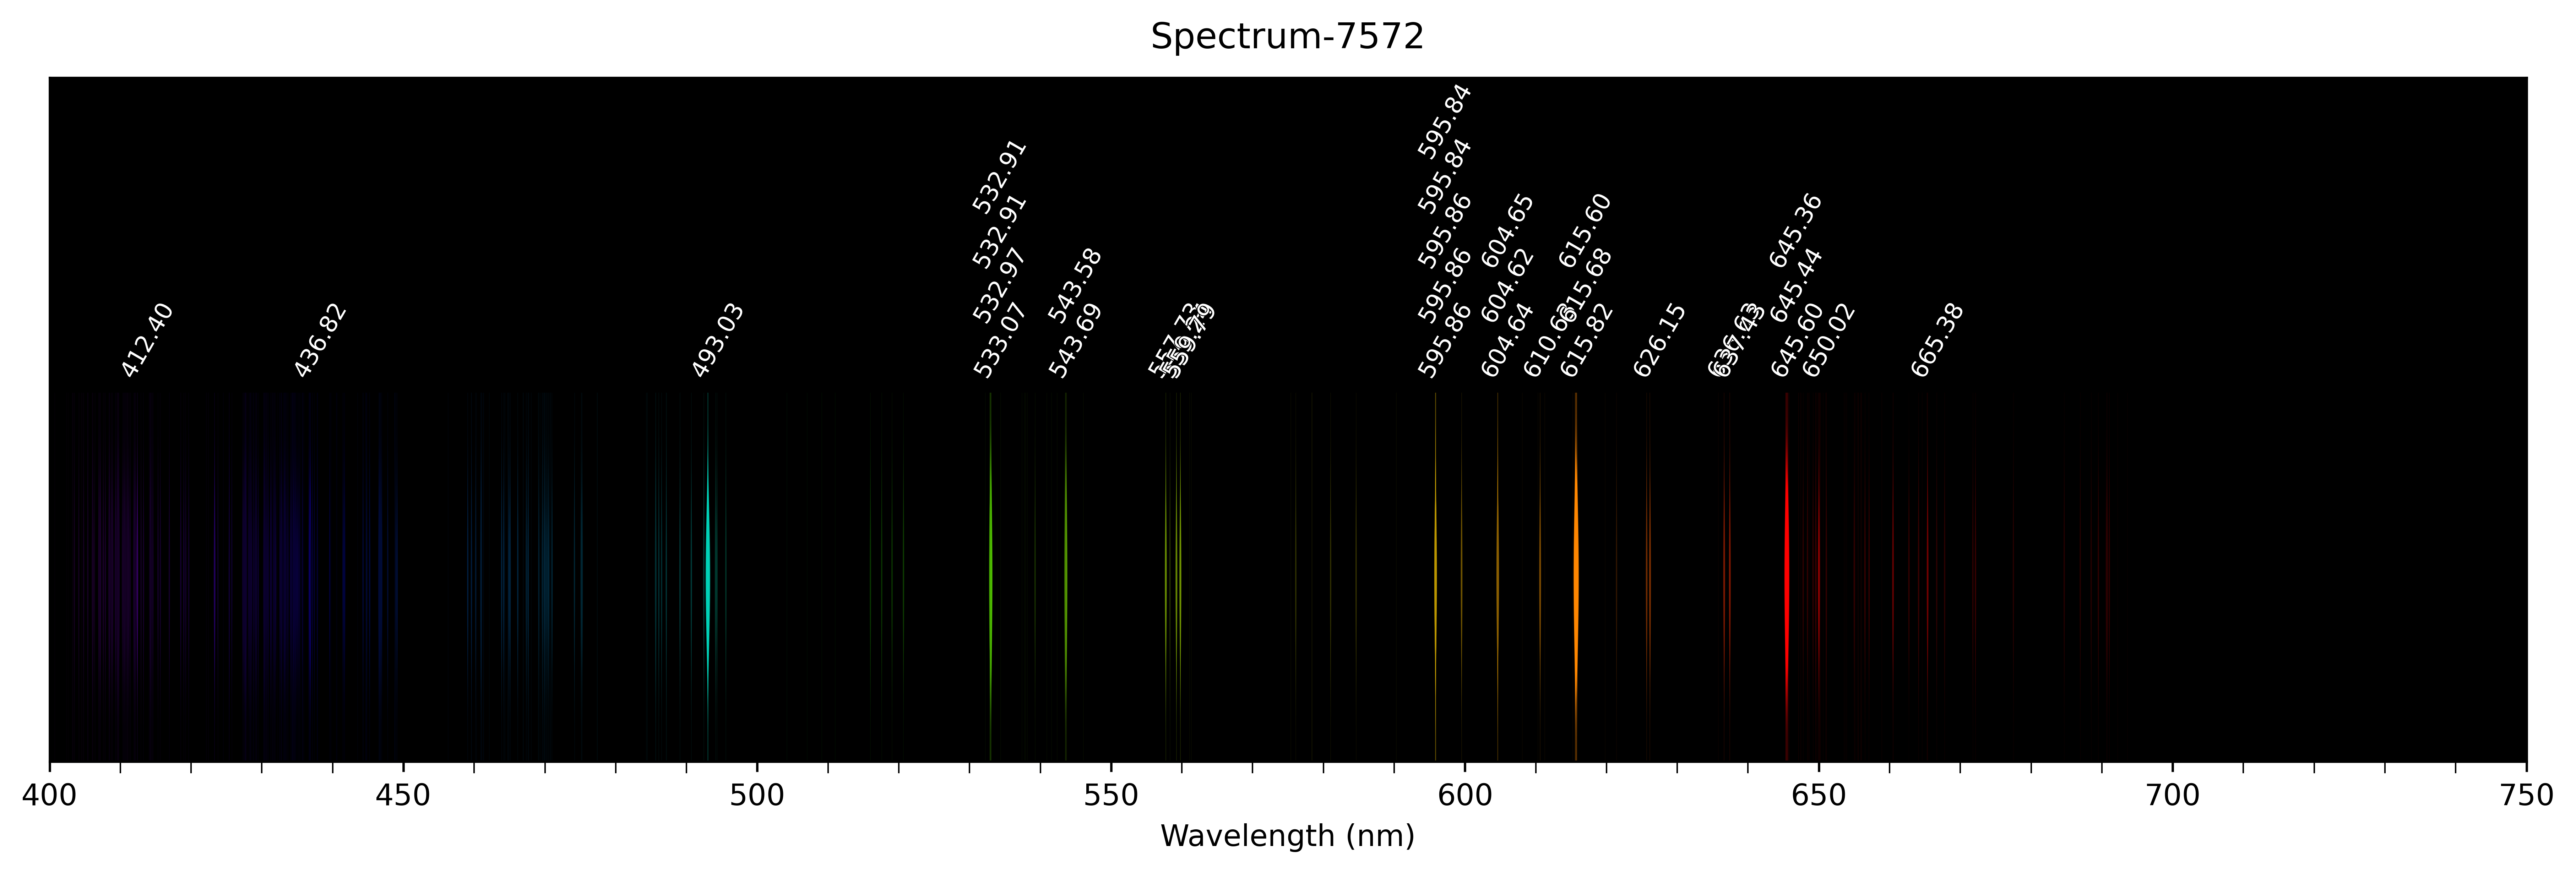

In [61]:
EXCEL_FILE_PATH = 'oxygen nist 2.xlsx'

df = pd.read_excel(EXCEL_FILE_PATH)


peak_label_y_position = 0.77   # where labels sit by default (0.0–1.0)
min_sep_nm = 0.4               # horizontal gap (nm) before labels start stacking
y_step = 0.01                  # vertical gap between stacked labels
label_max_y = 0.90             # hard ceiling for stacking

# --- DYNAMIC EXPANSION SETTINGS ---
fig_width = 15
fig_height_base = 3.0          # starting figure height (inches)
fig_height_overflow_scale = 9.0  # extra inches per unit of overflow
ylim_buffer = 0.25             # extra space above highest label
subplots_adjust_top = 0.85     # fraction of figure used by axes (0.85 = 15% top padding)

max_needle_y = 0.75


new_peak_y_posn = (peak_label_y * fig_height_base) 
peak_label_y_position = new_peak_y_posn

nist_fig = get_spec(data_df=df, mode='light')

# --- DYNAMIC HEIGHT EXPANSION ONLY ---

# --- DISPLAY ---


buf = io.BytesIO()
nist_fig.savefig(buf, format='png', bbox_inches='tight', dpi=DPI)

img = PILImage.open(buf)
print("fig size (in):", nist_fig.get_size_inches())
print("expected pixels (w,h):", tuple(int(x * nist_fig.dpi) for x in nist_fig.get_size_inches()))


print("saved image pixels (w,h):", img.size)


buf.seek(0)
display(Image(data=buf.getvalue()))

No NIST Destriptors Detected. Preparing Generic Rendering.

overflow: 0
o.g. peak label y pos'n: 0.77
Labels fit — no expansion needed
peak label y pos'n: 0.77
DEBUG: max_label_y = 0.77
len(peaks) 8 
base y:

 new peak label pos'n: 0.77
After plot_spec: fig height = 3.000"
base_y=0.77, y_step=0.08, min_sep_nm=0.4, max_y=0.90, height=3.0"
Before savefig: fig height = 3.000"
fig size (in): [15.  3.]
fig.dpi: 600
expected pixels (w,h): (9000, 1800)
saved image pixels (w,h): (7254, 1919)
saved bytes: 247270


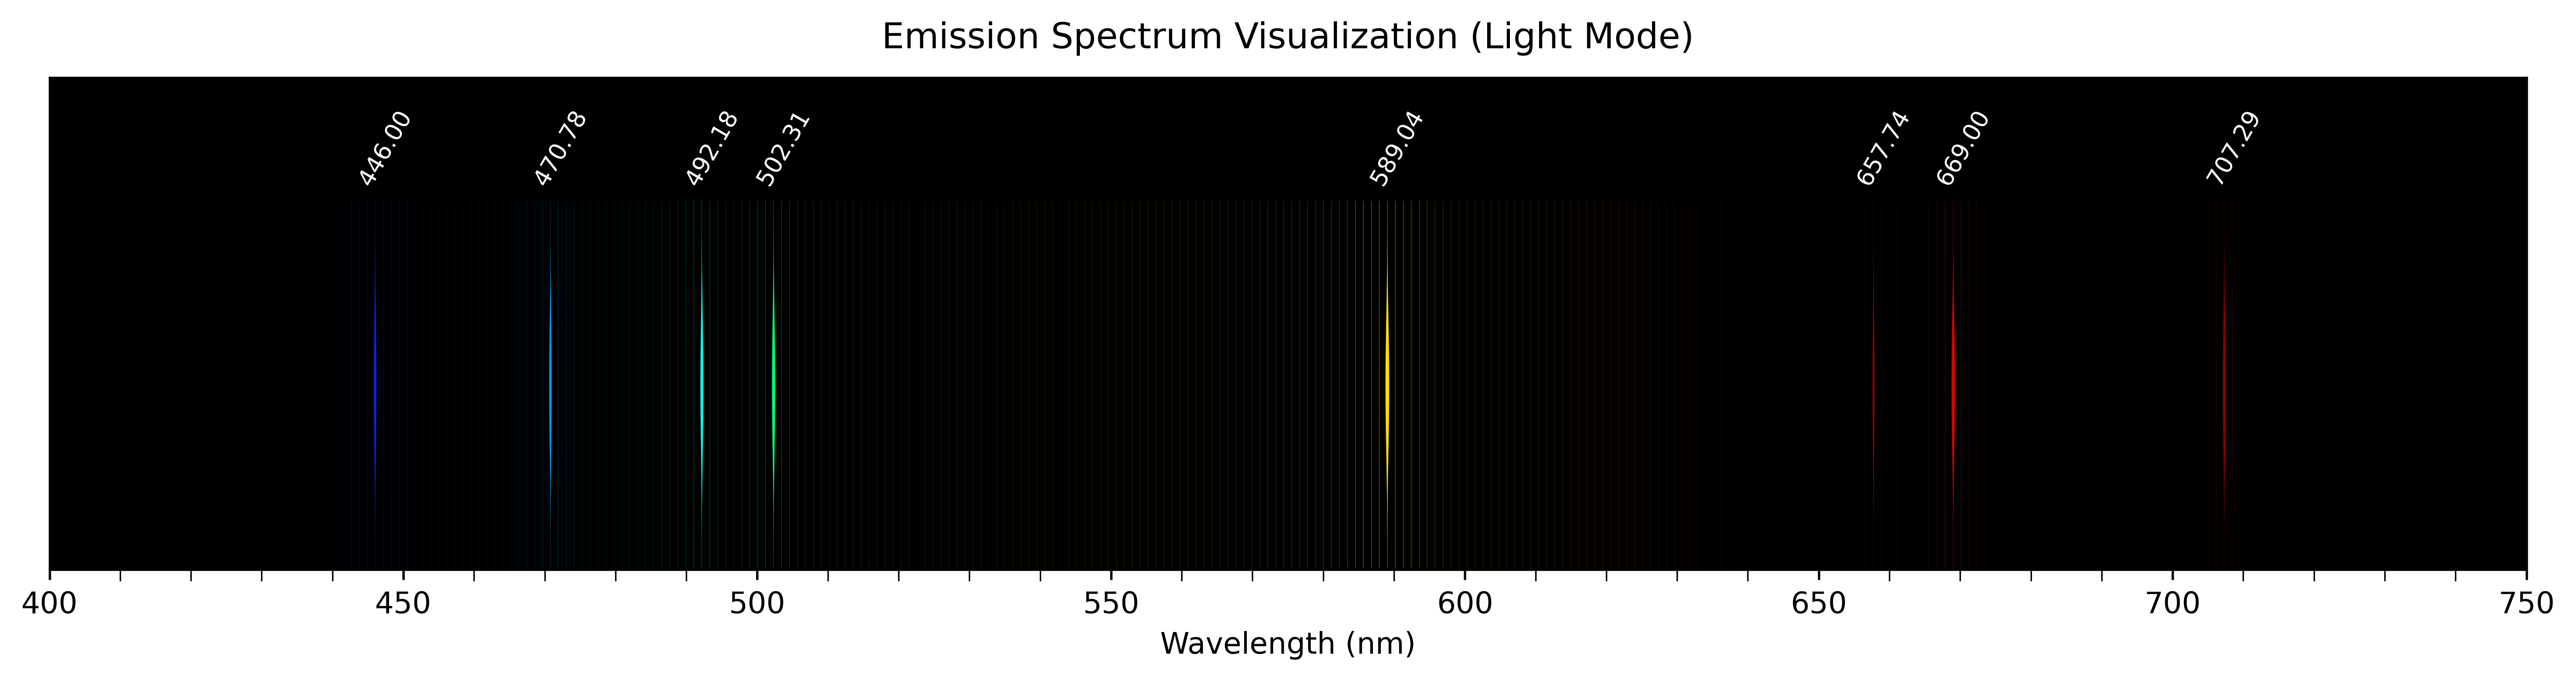

In [57]:
HELIUM_FILE_PATH = 'he test.xlsx'
HYDROGEN_FILE_PATH = 'h test.xlsx'

df_he = pd.read_excel(HELIUM_FILE_PATH)
df_h = pd.read_excel(HYDROGEN_FILE_PATH)

peak_label_y_position = 0.77   # where labels sit by default (0.0–1.0)
min_sep_nm = 0.4               # horizontal gap (nm) before labels start stacking
y_step = 0.08                  # vertical gap between stacked labels
label_max_y = 0.50             # hard ceiling for stacking

# --- DYNAMIC EXPANSION SETTINGS ---
fig_width = 15
fig_height_base = 3.0          # starting figure height (inches)
fig_height_overflow_scale = 9.0  # extra inches per unit of overflow
ylim_buffer = 0.25             # extra space above highest label
subplots_adjust_top = 0.85     # fraction of figure used by axes (0.85 = 15% top padding)

fig = plot_spec(
    data_df=df_he,
    mode='light',
    )

# --- DEBUG: check figure dimensions at each step ---
print(f"After plot_spec: fig height = {fig.get_figheight():.3f}\"")



# --- DISPLAY ---

print(f"base_y={peak_label_y_position}, y_step={y_step}, min_sep_nm={min_sep_nm}, max_y=0.90, height={fig.get_figheight():.1f}\"")

buf = io.BytesIO()

print(f"Before savefig: fig height = {fig.get_figheight():.3f}\"")
fig.savefig(buf, format='png', bbox_inches='tight', dpi=DPI)

img = PILImage.open(buf)
print("fig size (in):", fig.get_size_inches())
print("fig.dpi:", getattr(fig, "dpi", None))
print("expected pixels (w,h):", tuple(int(x * fig.dpi) for x in fig.get_size_inches()))
print("saved image pixels (w,h):", img.size)
print("saved bytes:", len(buf.getvalue()))

plt.close(fig)
buf.seek(0)
display(Image(data=buf.getvalue()))